In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available (NVIDIA): {torch.cuda.is_available()}")
print(f"MPS available (Apple Mac): {torch.backends.mps.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cpu
CUDA available (NVIDIA): False
MPS available (Apple Mac): False


In [1]:
### SETUP CELL - RUN ME ONCE
import os
import torch
import pandas as pd
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

# Import from your custom modules
from constants import TASK2_DATA
from pytorch_pipeline import ImageDataset, create_unfrozen_resnet
from evaluation import evaluate_resnet

save_path = "./plots/"
weights_path = "./finetuned_resnet_weights.pth"
batch_size = 32

# 1. Load data and recreate the exact validation split (so it's a fair test)
metadata = pd.read_csv(f"./datasets/{TASK2_DATA}/train_metadata.csv")
le = LabelEncoder()
metadata["encoded_label"] = le.fit_transform(metadata["class_name"])

_, val_df = train_test_split(
    metadata, test_size=0.2, random_state=2718, stratify=metadata["encoded_label"]
)

# 2. Image Preprocessing (Standard ImageNet formatting)
preprocess = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# 3. Build Validation Loader (No training loader needed!)
val_dataset = ImageDataset(
    val_df, base_dir=f"./datasets/{TASK2_DATA}/", transform=preprocess
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 4. Initialize model and load the trained weights
model = create_unfrozen_resnet(num_classes=10)

if os.path.exists(weights_path):
    print("Loading saved weights...")
    # Smart device detection
    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available() else "cpu"
    )

    # Load weights safely to whatever device is available
    saved_state_dict = torch.load(weights_path, map_location=device, weights_only=True)
    model.load_state_dict(saved_state_dict)

    print(f"Model successfully loaded and ready on {device}.")
else:
    print(f"ERROR: No weights found at {weights_path}.")
    print(
        "Please run your 'run_resnet_training()' function first to generate the .pth file!"
    )

Loading saved weights...
Model successfully loaded and ready on cpu.


Starting evaluation on the validation set...

========== Evaluating Unfrozen ResNet - Validation Accuracy ==========
Validation Accuracy: 86.90%
Saved matrix to ./plots/


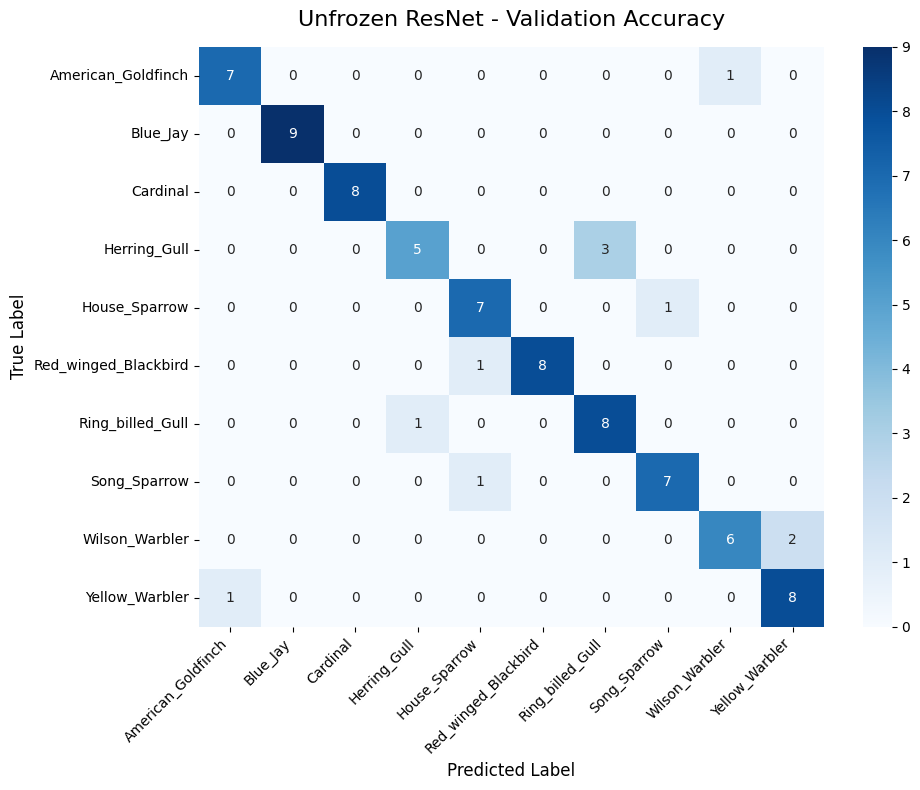

In [2]:
### EVALUATION CELL
print("Starting evaluation on the validation set...")

# Run the evaluation function (passing the LabelEncoder 'le' directly)
y_true, y_pred = evaluate_resnet(
    model=model,
    val_loader=val_loader,
    le=le,
    title="Unfrozen ResNet - Validation Accuracy",
    save_path=save_path,
)